# Import Dataset

In [1]:
import pandas as pd

df = pd.read_csv('../data/phishing_email_preprocessed.csv')
df.head()

,clean_text,label,label_encoded,text_length,word_count,digit_count,uppercase_count,special_char_count,has_url,has_email
0,hpl nom may see attached file hplno xls hplno xls,0,0,-1.015682,-0.265507,-0.014909,-0.00399,-0.177516,0,0
1,nom actual vols th forwarded sabrae zajac hou ...,0,0,0.127212,0.019503,-0.014909,-0.00399,-0.177516,0,0
2,enron actuals march april estimated actuals ma...,0,0,-0.933162,-0.251457,-0.014909,-0.00399,-0.177516,0,0
3,hpl nom may see attached file hplno xls hplno xls,0,0,-1.015682,-0.265507,-0.014909,-0.00399,-0.177516,0,0
4,hpl nom june see attached file hplno xls hplno...,0,0,-1.014306,-0.265507,-0.014909,-0.00399,-0.177516,0,0


# Shape, Columns, Information

In [2]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82077 entries, 0 to 82076
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   clean_text          82076 non-null  object 
 1   label               82077 non-null  int64  
 2   label_encoded       82077 non-null  int64  
 3   text_length         82077 non-null  float64
 4   word_count          82077 non-null  float64
 5   digit_count         82077 non-null  float64
 6   uppercase_count     82077 non-null  float64
 7   special_char_count  82077 non-null  float64
 8   has_url             82077 non-null  int64  
 9   has_email           82077 non-null  int64  
dtypes: float64(5), int64(4), object(1)
memory usage: 6.3+ MB


# features

In [3]:
X = df['clean_text']
y = df['label_encoded']

# Splitting

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [5]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(65661,) (16416,) (65661,) (16416,)


# Convert text into numerical form

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer


X_train = X_train.fillna('')
X_test = X_test.fillna('')

tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [8]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(65661, 5000)
(16416, 5000)


# Train Logistic Regression

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9806895711500975
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      7847
           1       0.98      0.98      0.98      8569

    accuracy                           0.98     16416
   macro avg       0.98      0.98      0.98     16416
weighted avg       0.98      0.98      0.98     16416

[[7663  184]
 [ 133 8436]]


# Train Random Forest

In [10]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_tfidf, y_train)

y_pred_rf = rf_model.predict(X_test_tfidf)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.9819078947368421
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      7847
           1       0.98      0.98      0.98      8569

    accuracy                           0.98     16416
   macro avg       0.98      0.98      0.98     16416
weighted avg       0.98      0.98      0.98     16416

[[7713  134]
 [ 163 8406]]


# Train SVM

In [11]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))

c:\Users\USER\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


SVM Accuracy: 0.9841617933723197
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      7847
           1       0.98      0.99      0.98      8569

    accuracy                           0.98     16416
   macro avg       0.98      0.98      0.98     16416
weighted avg       0.98      0.98      0.98     16416

[[7696  151]
 [ 109 8460]]


# Simple Comparison

In [12]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'SVM'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_svm)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.980690
1        Random Forest  0.981908
2                  SVM  0.984162


# Bar Chart

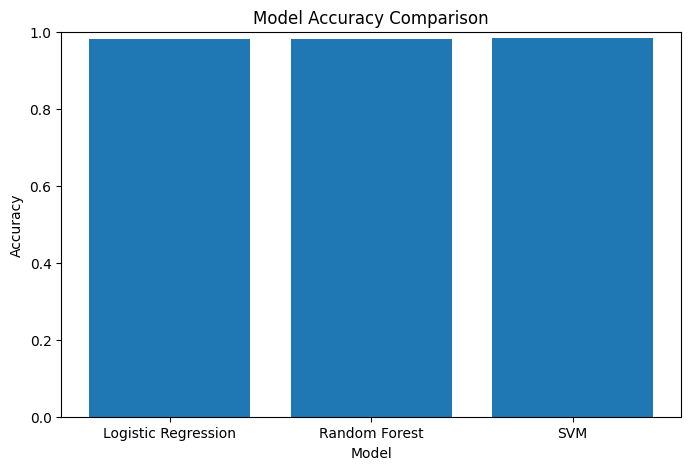

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(results['Model'], results['Accuracy'])
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.show()

# Confusion Matrix

=== Logistic Regression ===
Accuracy: 0.9806895711500975

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      7847
           1       0.98      0.98      0.98      8569

    accuracy                           0.98     16416
   macro avg       0.98      0.98      0.98     16416
weighted avg       0.98      0.98      0.98     16416

Confusion Matrix:
 [[7663  184]
 [ 133 8436]]


<Figure size 600x500 with 0 Axes>

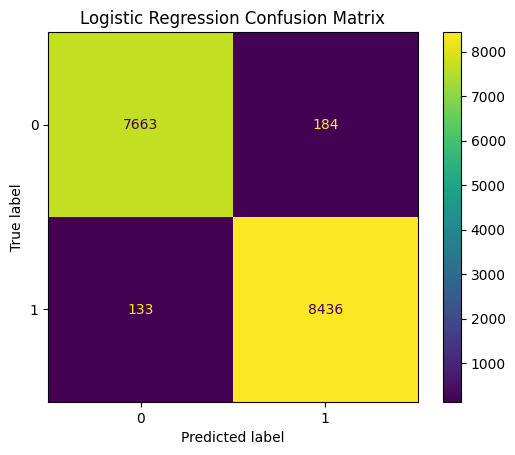

=== Random Forest ===
Accuracy: 0.9819078947368421

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      7847
           1       0.98      0.98      0.98      8569

    accuracy                           0.98     16416
   macro avg       0.98      0.98      0.98     16416
weighted avg       0.98      0.98      0.98     16416

Confusion Matrix:
 [[7713  134]
 [ 163 8406]]


<Figure size 600x500 with 0 Axes>

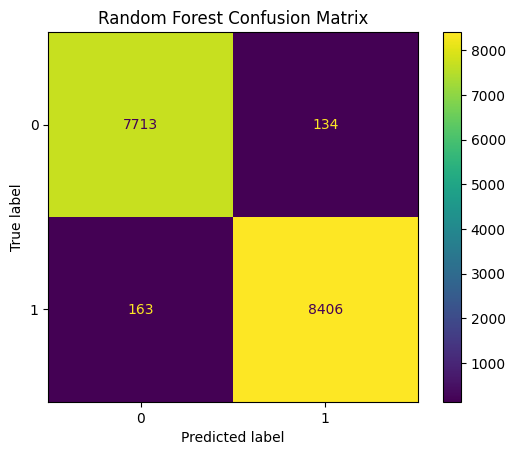

=== SVM ===
Accuracy: 0.9841617933723197

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.98      7847
           1       0.98      0.99      0.98      8569

    accuracy                           0.98     16416
   macro avg       0.98      0.98      0.98     16416
weighted avg       0.98      0.98      0.98     16416

Confusion Matrix:
 [[7696  151]
 [ 109 8460]]


<Figure size 600x500 with 0 Axes>

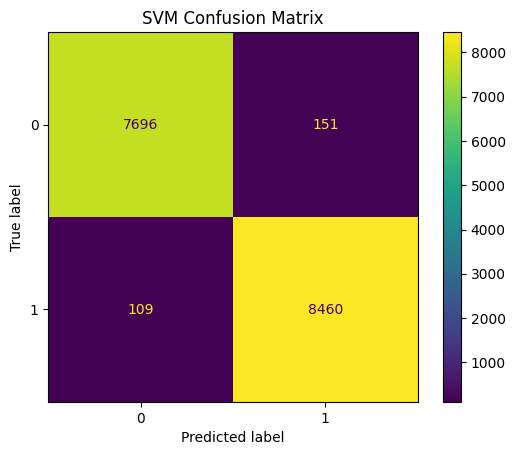

In [15]:
# =========================
# Step 10: Confusion Matrix and Evaluation Visuals
# =========================

import matplotlib.pyplot as plt
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix
)

# -------------------------
# Logistic Regression
# -------------------------
print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr)
plt.title("Logistic Regression Confusion Matrix")
plt.show()


# -------------------------
# Random Forest
# -------------------------
print("=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Random Forest Confusion Matrix")
plt.show()


# -------------------------
# SVM
# -------------------------
print("=== SVM ===")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm)
plt.title("SVM Confusion Matrix")
plt.show()

In [17]:
results.to_csv('../results/model_comparison_week4.csv', index=False)

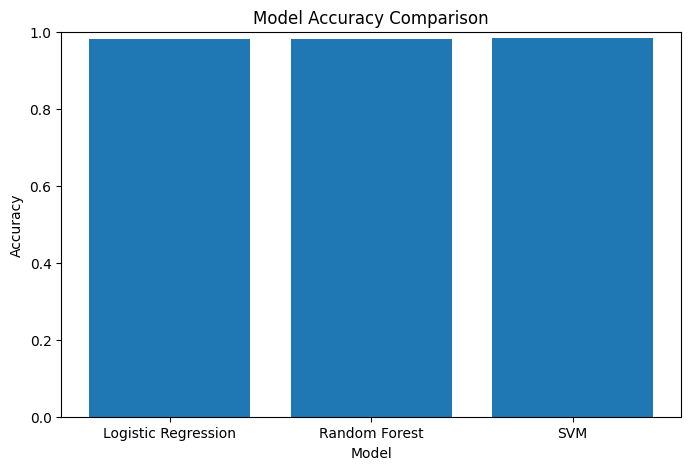

In [18]:
plt.figure(figsize=(8,5))
plt.bar(results['Model'], results['Accuracy'])
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.savefig('../results/model_accuracy_comparison.png')
plt.show()